# ResNet-50 | Fine-tuning (Transfer Learning)
Multi-label clothing classification - 5 classes  
Init: ImageNet pretrained | Frozen: conv1, bn1, layer1, layer2 | Trainable: layer3, layer4, fc  
Loss: BCEWithLogitsLoss + pos_weight | Threshold: 0.5

## 1. Configuration

In [ ]:
import os, glob, pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


BASE_DIR = '/kaggle/input/datasets/fashion/processed'

TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'train', 'images')
VAL_IMG_DIR   = os.path.join(BASE_DIR, 'validation', 'images')

print(f'Dataset root : {BASE_DIR}')
print(f'Train images : {TRAIN_IMG_DIR}')
print(f'Val   images : {VAL_IMG_DIR}')

BATCH_SIZE  = 64
NUM_CLASSES = 5
NUM_EPOCHS  = 25     
LR          = 1e-4   
WEIGHT_DECAY = 1e-4
PATIENCE    = 5
THRESHOLD   = 0.5
CKPT        = '/kaggle/working/resnet50_finetune_best.pth'
CLASS_NAMES = ['short_sleeve_top', 'trousers', 'shorts',
               'long_sleeve_top', 'skirt']

FREEZE = ['conv1', 'bn1', 'layer1', 'layer2']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

## 2. Load Labels

In [ ]:
with open(os.path.join(BASE_DIR, 'train_labels.pkl'), 'rb') as f:
    train_labels = pickle.load(f)
with open(os.path.join(BASE_DIR, 'val_labels.pkl'), 'rb') as f:
    val_labels = pickle.load(f)

train_arr = np.array(list(train_labels.values()))  

print(f'Train: {len(train_labels):,}  |  Val: {len(val_labels):,}')
print('\nClass positives in train:')
for i, c in enumerate(CLASS_NAMES):
    p = int(train_arr[:, i].sum())
    print(f'  {c:<20}: {p:>6}  ({p/len(train_arr)*100:.1f}%)')

Train: 144,174  |  Val: 23,741

Class positives in train:
  short_sleeve_top    :  70586  (49.0%)
  trousers            :  54969  (38.1%)
  shorts              :  36332  (25.2%)
  long_sleeve_top     :  35751  (24.8%)
  skirt               :  30625  (21.2%)


## 3. Dataset & DataLoader

In [3]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class FashionDataset(Dataset):
    def __init__(self, labels_dict, img_root, transform=None):
        self.labels    = labels_dict
        self.filenames = list(labels_dict.keys())
        self.transform = transform
        self.img_root  = img_root

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, i):
        fname = self.filenames[i]
        img   = Image.open(os.path.join(self.img_root, fname)).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[fname], dtype=torch.float32)
        return img, label

_mean = [0.485, 0.456, 0.406]
_std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=_mean, std=_std),
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=_mean, std=_std),
])

train_ds = FashionDataset(train_labels, TRAIN_IMG_DIR, train_tf)
val_ds   = FashionDataset(val_labels,   VAL_IMG_DIR,   val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')
xb, yb = next(iter(train_loader))
print('Batch image shape:', xb.shape)

Train batches: 2253 | Val batches: 371
Batch image shape: torch.Size([64, 3, 224, 224])


## 4. Model - Pretrained + Selective Freezing

In [4]:
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

for name, param in model.named_parameters():
    if any(name.startswith(l) for l in FREEZE):
        param.requires_grad = False

model.fc = nn.Linear(2048, NUM_CLASSES)
nn.init.kaiming_normal_(model.fc.weight, mode='fan_out', nonlinearity='relu')
nn.init.constant_(model.fc.bias, 0.0)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f'Trainable: {trainable:,} | Frozen: {frozen:,}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]


Trainable: 22,073,349 | Frozen: 1,444,928


## 5. Loss, Optimizer & Scheduler

In [5]:
pos        = train_arr.sum(axis=0)
neg        = len(train_arr) - pos
pos_weight = torch.tensor(neg / pos, dtype=torch.float32).to(device)

print('pos_weight per class:')
for name, w in zip(CLASS_NAMES, pos_weight.cpu().tolist()):
    print(f'  {name:<20}: {w:.3f}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Only pass trainable params to optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

pos_weight per class:
  short_sleeve_top    : 1.043
  trousers            : 1.623
  shorts              : 2.968
  long_sleeve_top     : 3.033
  skirt               : 3.708


## 6. Evaluation Function

In [6]:
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score

def evaluate(model, loader, criterion=None):
    model.eval()
    probs_list, labels_list = [], []
    total_vloss = 0.0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs_d, lbls_d = imgs.to(device), lbls.to(device)
            logits = model(imgs_d)
            probs_list.append(torch.sigmoid(logits).cpu().numpy())
            labels_list.append(lbls.numpy())
            if criterion:
                total_vloss += criterion(logits, lbls_d).item() * imgs.size(0)

    probs  = np.vstack(probs_list)
    labels = np.vstack(labels_list)
    preds  = (probs >= THRESHOLD).astype(int)

    per_class = {}
    for i, cls in enumerate(CLASS_NAMES):
        tp = int(((preds[:,i]==1) & (labels[:,i]==1)).sum())
        fp = int(((preds[:,i]==1) & (labels[:,i]==0)).sum())
        tn = int(((preds[:,i]==0) & (labels[:,i]==0)).sum())
        fn = int(((preds[:,i]==0) & (labels[:,i]==1)).sum())
        prec = tp / (tp + fp + 1e-8)
        rec  = tp / (tp + fn + 1e-8)
        f1   = 2*prec*rec / (prec + rec + 1e-8)
        auc  = roc_auc_score(labels[:,i], probs[:,i])
        ap   = average_precision_score(labels[:,i], probs[:,i])
        per_class[cls] = dict(TP=tp, FP=fp, TN=tn, FN=fn,
                               Precision=prec, Recall=rec, F1=f1, AUC=auc, AP=ap)

    macro_f1 = float(np.mean([v['F1'] for v in per_class.values()]))
    ttp = sum(v['TP'] for v in per_class.values())
    tfp = sum(v['FP'] for v in per_class.values())
    tfn = sum(v['FN'] for v in per_class.values())
    mp  = ttp / (ttp + tfp + 1e-8)
    mr  = ttp / (ttp + tfn + 1e-8)
    micro_f1 = 2*mp*mr / (mp + mr + 1e-8)

    hamming_acc = float((preds == labels).mean())
    exact_match = float((preds == labels).all(axis=1).mean())
    mAP         = float(np.mean([v['AP'] for v in per_class.values()]))

    val_loss = total_vloss / len(loader.dataset) if criterion else None
    return per_class, macro_f1, micro_f1, hamming_acc, exact_match, mAP, probs, labels, val_loss

## 7. Training

In [7]:
history = {'train_loss':[], 'val_loss':[], 'macro_f1':[], 'micro_f1':[]}
best_macro_f1  = 0.0
patience_count = 0
scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    run_loss = 0.0
    for imgs, lbls in tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS}', leave=False):
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad(set_to_none=True)
        if scaler:
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                loss = criterion(model(imgs), lbls)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss = criterion(model(imgs), lbls)
            loss.backward()
            optimizer.step()
        run_loss += loss.item() * imgs.size(0)
    train_loss = run_loss / len(train_ds)

    per_class, macro_f1, micro_f1, hamming_acc, exact_match, mAP, _, _, val_loss = \
        evaluate(model, val_loader, criterion)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['macro_f1'].append(macro_f1)
    history['micro_f1'].append(micro_f1)

    print(f'Ep {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | '
          f'macro_f1={macro_f1:.4f} | micro_f1={micro_f1:.4f} | '
          f'hamming={hamming_acc:.4f} | mAP={mAP:.4f}')
    scheduler.step(macro_f1)

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        patience_count = 0
        torch.save({
            'epoch'            : epoch,
            'model_state_dict' : model.state_dict(),
            'macro_f1'         : macro_f1,
            'micro_f1'         : micro_f1,
            'per_class_metrics': per_class,
        }, CKPT)
        print(f'  ✓ Best model saved (macro-F1={macro_f1:.4f})')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}.')
            break

print(f'\nBest val macro-F1: {best_macro_f1:.4f}')

Epoch 1/25:   0%|          | 0/2253 [00:00<?, ?it/s]

Ep 01 | train_loss=0.6378 | val_loss=0.4525 | macro_f1=0.7668 | micro_f1=0.7858 | hamming=0.8528 | mAP=0.8687
  ✓ Best model saved (macro-F1=0.7668)


Epoch 2/25:   0%|          | 0/2253 [00:00<?, ?it/s]

Ep 02 | train_loss=0.3969 | val_loss=0.4236 | macro_f1=0.7914 | micro_f1=0.8075 | hamming=0.8674 | mAP=0.8877
  ✓ Best model saved (macro-F1=0.7914)


Epoch 3/25:   0%|          | 0/2253 [00:00<?, ?it/s]

...

Ep 16 | train_loss=0.0436 | val_loss=0.8688 | macro_f1=0.8038 | micro_f1=0.8224 | hamming=0.8860 | mAP=0.8882


Epoch 17/25:   0%|          | 0/2253 [00:00<?, ?it/s]

Ep 17 | train_loss=0.0411 | val_loss=0.8054 | macro_f1=0.8012 | micro_f1=0.8180 | hamming=0.8806 | mAP=0.8869


Epoch 18/25:   0%|          | 0/2253 [00:00<?, ?it/s]

Ep 18 | train_loss=0.0271 | val_loss=0.8508 | macro_f1=0.8104 | micro_f1=0.8265 | hamming=0.8878 | mAP=0.8943

Early stopping at epoch 18.

Best val macro-F1: 0.8107


## 8. Final Evaluation (best checkpoint)

In [8]:
ckpt = torch.load(CKPT, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
per_class, macro_f1, micro_f1, hamming_acc, exact_match, mAP, all_probs, all_labels, _ = \
    evaluate(model, val_loader, criterion)

print('=' * 88)
print(f'  ResNet-50 Fine-tuned  |  Best epoch: {ckpt["epoch"]}  |  Threshold: {THRESHOLD}')
print('=' * 88)
print(f'{"Class":<22} {"TP":>7} {"FP":>7} {"TN":>7} {"FN":>7} '
      f'{"Prec":>7} {"Rec":>7} {"F1":>7} {"AUC":>7} {"AP":>7}')
print('-' * 88)
for cls in CLASS_NAMES:
    m = per_class[cls]
    print(f'{cls:<22} {m["TP"]:>7} {m["FP"]:>7} {m["TN"]:>7} {m["FN"]:>7} '
          f'{m["Precision"]:>7.4f} {m["Recall"]:>7.4f} {m["F1"]:>7.4f} '
          f'{m["AUC"]:>7.4f} {m["AP"]:>7.4f}')
print('-' * 88)
print(f'{"Macro-F1":<22} {macro_f1:>7.4f}')
print(f'{"Micro-F1":<22} {micro_f1:>7.4f}')
print(f'{"mAP":<22} {mAP:>7.4f}')
print(f'{"Hamming Accuracy":<22} {hamming_acc:>7.4f}')
print(f'{"Exact Match":<22} {exact_match:>7.4f}')

  ResNet-50 Fine-tuned  |  Best epoch: 13  |  Threshold: 0.5
Class                       TP      FP      TN      FN    Prec     Rec      F1     AUC      AP
----------------------------------------------------------------------------------------
short_sleeve_top         10263    1475    9895    2108  0.8743  0.8296  0.8514  0.9340  0.9419
trousers                  8078    1392   12855    1416  0.8530  0.8509  0.8519  0.9518  0.9373
shorts                    3133    1175   18433    1000  0.7273  0.7580  0.7423  0.9401  0.8361
long_sleeve_top           4668    1706   16119    1248  0.7324  0.7890  0.7596  0.9329  0.8379
skirt                     5395     824   16418    1104  0.8675  0.8301  0.8484  0.9651  0.9220
----------------------------------------------------------------------------------------
Macro-F1                0.8107
Micro-F1                0.8243
mAP                     0.8951
Hamming Accuracy        0.8867
Exact Match             0.6142


## 9. ROC Curves

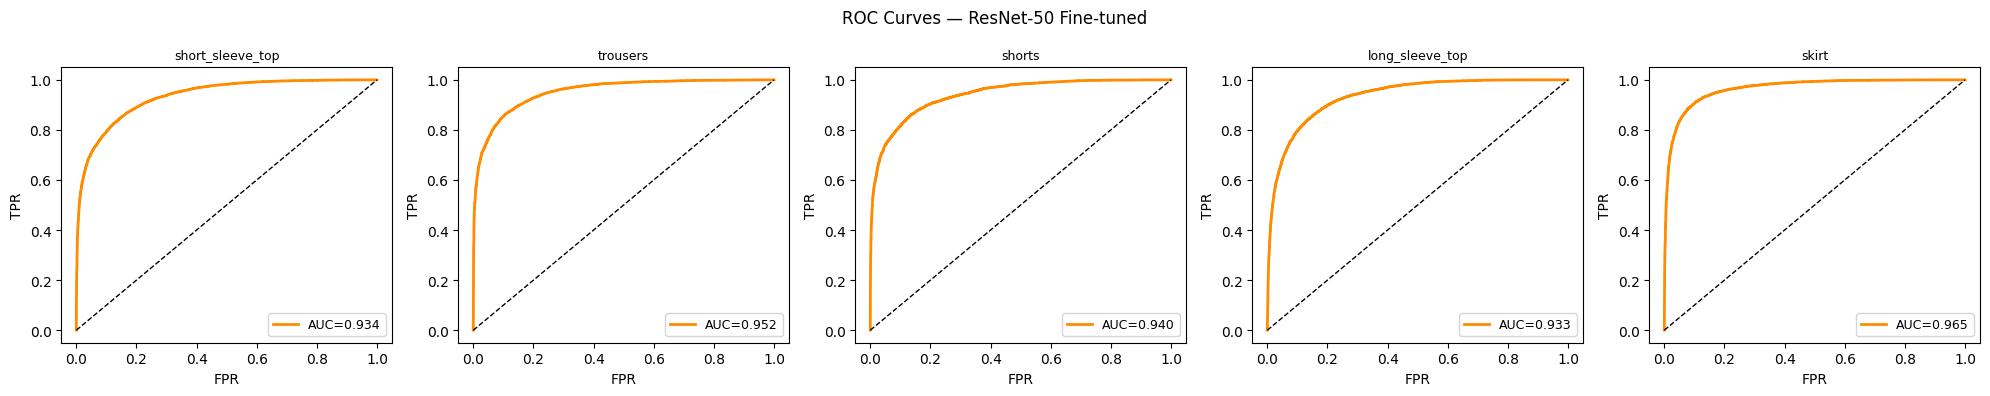

In [9]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 4))
for i, (cls, ax) in enumerate(zip(CLASS_NAMES, axes)):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    ax.plot(fpr, tpr, lw=2, color='darkorange', label=f'AUC={per_class[cls]["AUC"]:.3f}')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_title(cls, fontsize=9)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=9)
plt.suptitle('ROC Curves — ResNet-50 Fine-tuned', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/roc_finetune.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Training Curves

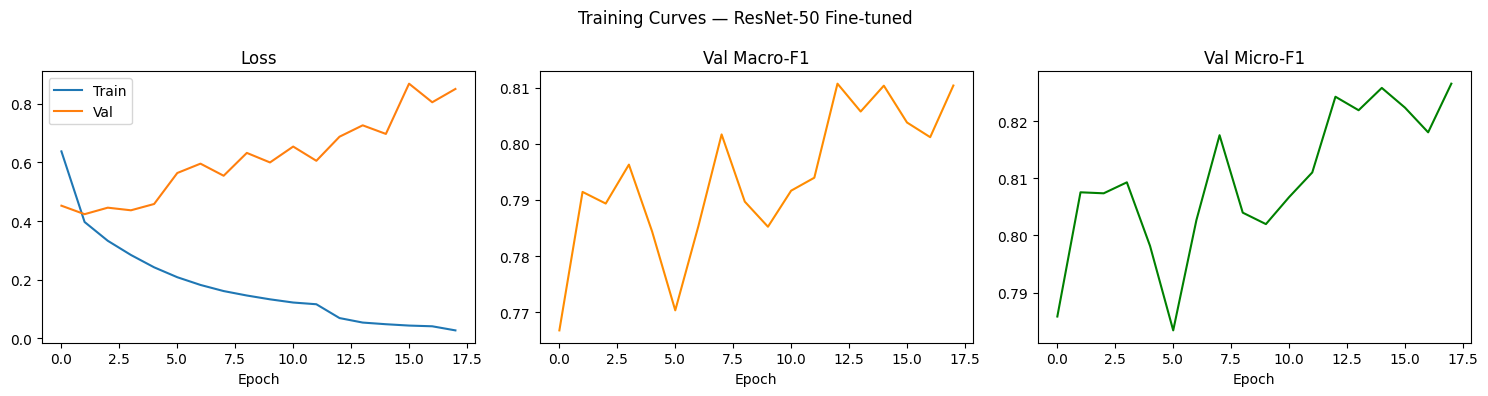

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history['macro_f1'], color='darkorange')
axes[1].set_title('Val Macro-F1'); axes[1].set_xlabel('Epoch')
axes[2].plot(history['micro_f1'], color='green')
axes[2].set_title('Val Micro-F1'); axes[2].set_xlabel('Epoch')
plt.suptitle('Training Curves — ResNet-50 Fine-tuned', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/curves_finetune.png', dpi=150, bbox_inches='tight')
plt.show()